# 08 · Air quality: a map is not an exposure estimate

**Time:** 35 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Inspect spatial gradients and distinguish surface pollution, atmospheric columns, and human exposure.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=08_air_quality.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Identify the quantity

Our synthetic field is labeled illustrative surface PM2.5 in µg/m³. It is not CAMS output or station data.
Satellite aerosol optical depth is a column optical quantity; it cannot be renamed surface PM2.5 without a justified retrieval or model.
For a real extension, inspect the [Copernicus Atmosphere Data Store](https://ads.atmosphere.copernicus.eu/) and the selected product documentation.

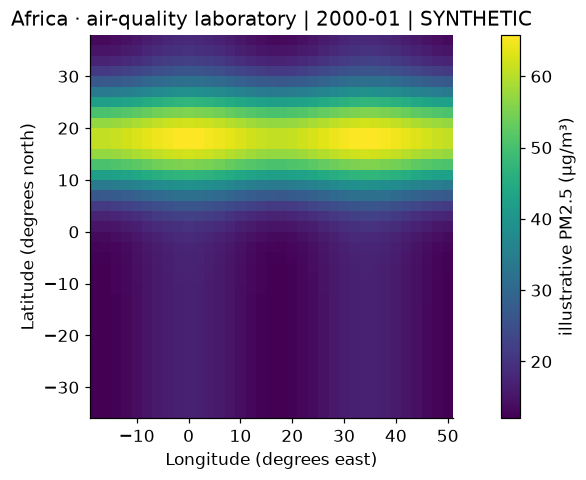

In [2]:
meta,air=load_cube('air')
map_slice(meta,air,0);plt.show()

## 2. Compare regions with explicit spatial support

These boxes are latitude bands, not administrative regions. Their means include ocean cells.
Neither is population weighted. A visually tall column in the lab only encodes scaled value.

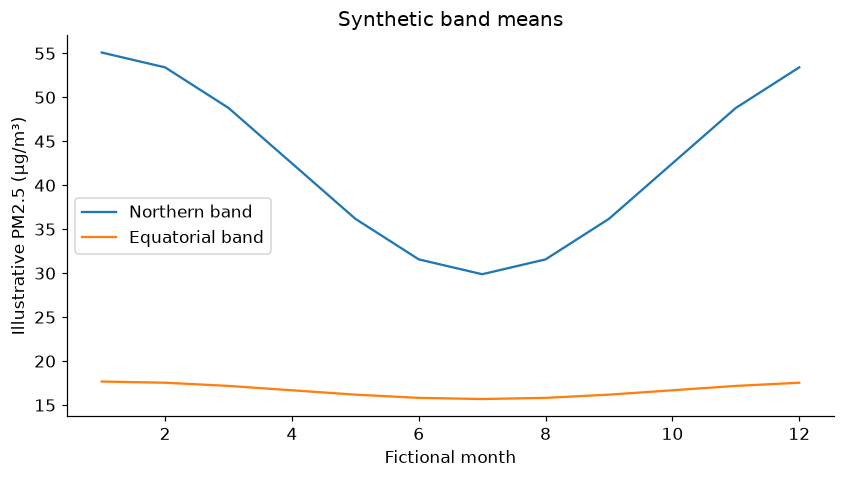

In [3]:
con=sql_connection(meta,air)
for label,lo,hi in [('Northern band',10,25),('Equatorial band',-5,5)]:
    result=list(con.execute('SELECT t, AVG(value) FROM cells WHERE lat BETWEEN ? AND ? GROUP BY t ORDER BY t',(lo,hi)))
    plt.plot([r[0]+1 for r in result],[r[1] for r in result],label=label)
plt.xlabel('Fictional month');plt.ylabel('Illustrative PM2.5 (µg/m³)');plt.title('Synthetic band means');plt.legend();plt.show()

## 3. Ask what an exposure model needs

Explore changes under a chosen threshold without attaching regulatory or health meanings to it.
Actual exposure depends on where and when people are present, indoor conditions, and many other factors.
Spatial alignment, units, averaging period, and missing-data handling must be checked before joining population and pollution grids.

In [4]:
threshold=35
print('Synthetic cell-months above chosen threshold:',np.count_nonzero(air>threshold))
lab('air','columns')

Synthetic cell-months above chosen threshold: 2520


## Try it yourself

Explain why “largest average concentration” and “largest total population exposure” could identify different regions.

## Check your reasoning

A concentration map weights location; an exposure estimate weights people and time. Both require transparent assumptions and appropriate observations.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.
- [Copernicus Atmosphere Monitoring Service](https://atmosphere.copernicus.eu/)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.